In [11]:
#1 - Data Description

#load everything
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#working with the data and making a dataframe

df = pd.read_csv("Mangrove Combined Data.csv", sep = ",")
#mean 
print("Mean Values:")
df[['Soil pH','Soil Salinity ','Total ECS']].mean(axis=0)


Mean Values:


Soil pH             6.040625
Soil Salinity      14.121875
Total ECS         418.535298
dtype: float64

In [4]:
#median
print("Median Values:")
df[['Soil pH','Soil Salinity ','Total ECS']].median(axis=0)

Median Values:


Soil pH             6.200000
Soil Salinity      17.000000
Total ECS         436.642215
dtype: float64

In [5]:
#standard deviation
print("Standard Devation Values:")
df[['Soil pH','Soil Salinity ','Total ECS']].std(axis=0)

Standard Devation Values:


Soil pH             0.658375
Soil Salinity      10.317218
Total ECS         207.232716
dtype: float64

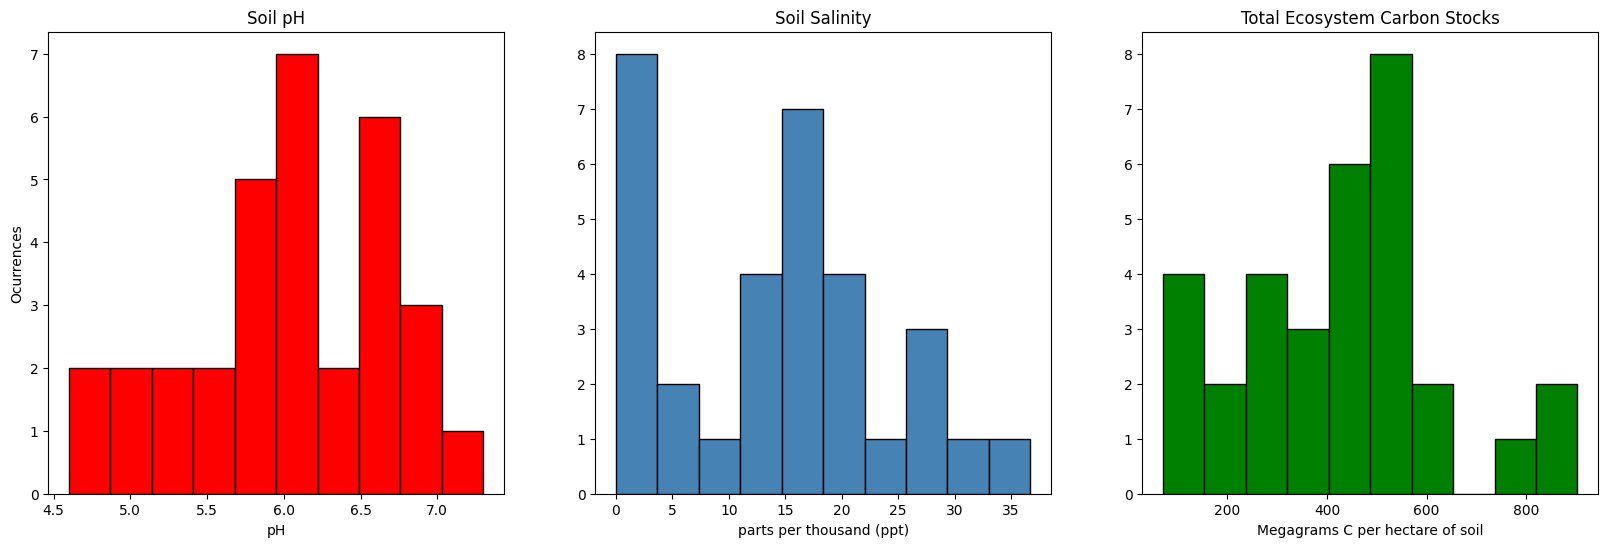

In [6]:
#histograms of revelant variables (pH, salinity, TECS)

fig, axes = plt.subplots(1, 3, figsize = (20,6))

df['Soil pH'].hist(ax= axes[0], bins=10, color = 'red', edgecolor = 'black')
axes[0].set_title('Soil pH')
axes[0].set_xlabel('pH')
axes[0].set_ylabel('Ocurrences')
axes[0].grid(False)
plt.savefig('histogram_pH.png', dpi=300, bbox_inches='tight')

df['Soil Salinity '].hist(ax= axes[1], bins=10, color = 'steelblue', edgecolor = 'black')
axes[1].set_title('Soil Salinity')
axes[1].set_xlabel('parts per thousand (ppt)')
axes[1].grid(False)
plt.savefig('histogram_salinity.png', dpi=300, bbox_inches='tight')

df['Total ECS'].hist(ax= axes[2], bins=10, color = 'green', edgecolor = 'black')
axes[2].set_title('Total Ecosystem Carbon Stocks')
axes[2].set_xlabel('Megagrams C per hectare of soil')
axes[2].grid(False)
plt.savefig('histogram_TECS.png', dpi=300, bbox_inches='tight')



In [7]:
#2 - Correlation

from scipy.stats import pearsonr
from scipy.stats import spearmanr

#pearson
pearson_corr = df[['Soil pH', 'Soil Salinity ','Total ECS']].corr(method = 'pearson')
print("Pearson Correlation Coefficient Values:")
print(pearson_corr)
print(" ")

#spearman
spearman_corr = df[['Soil pH', 'Soil Salinity ','Total ECS']].corr(method = 'spearman')
print("Spearman Correlation Coefficient Values:")
print(spearman_corr)


Pearson Correlation Coefficient Values:
                 Soil pH  Soil Salinity   Total ECS
Soil pH         1.000000        0.406807   0.125752
Soil Salinity   0.406807        1.000000  -0.237285
Total ECS       0.125752       -0.237285   1.000000
 
Spearman Correlation Coefficient Values:
                 Soil pH  Soil Salinity   Total ECS
Soil pH         1.000000        0.348035   0.094809
Soil Salinity   0.348035        1.000000  -0.170678
Total ECS       0.094809       -0.170678   1.000000


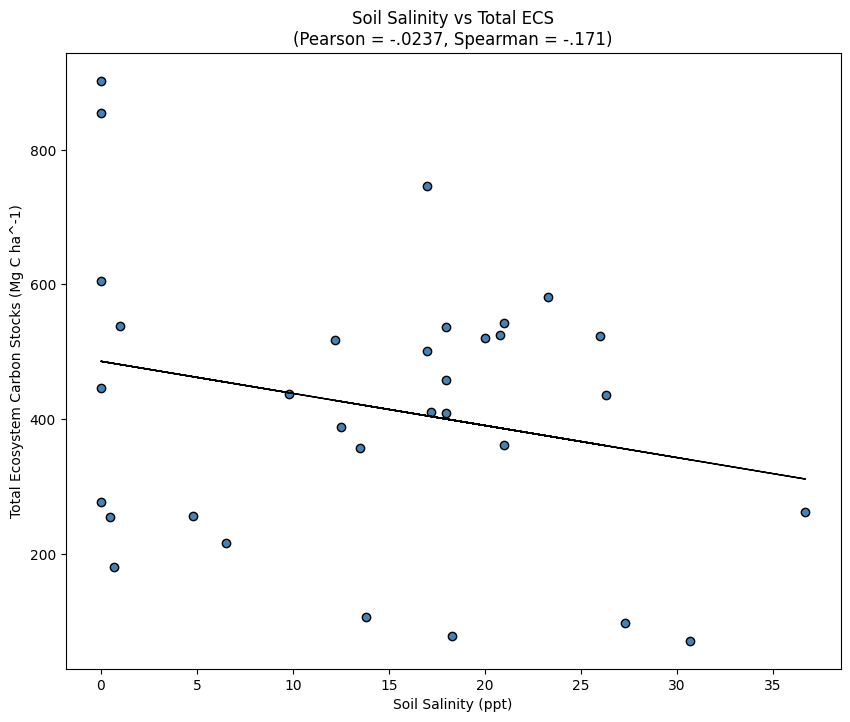

Linear Regression Equation:
y =  -4.766x + 485.842
 
R squared value:
R2 = 0.056


<Figure size 640x480 with 0 Axes>

In [9]:
#salinity vs ECS linear regression and scatter plot

from scipy.stats import linregress

LR = stats.linregress(df['Soil Salinity '], df[ 'Total ECS'])

#create scatter plot
plt.figure(figsize = (10,8))
plt.scatter(df['Soil Salinity '], df['Total ECS'], color = 'steelblue', edgecolor = 'black')

#making regression line overlaid on plot
x = df['Soil Salinity ']
y_reg = LR.slope*x + LR.intercept
plt.plot(x, y_reg, 'k-', linewidth = 1)

plt.xlabel('Soil Salinity (ppt)')
plt.ylabel('Total Ecosystem Carbon Stocks (Mg C ha^-1)')
plt.title(f'Soil Salinity vs Total ECS\n(Pearson = -.0237, Spearman = -.171)')
plt.grid(False)
plt.show()
plt.savefig('salinityscatter.png', dpi=300, bbox_inches='tight')

print("Linear Regression Equation:")
print("y = ", str(np.round(LR.slope, decimals=3)) + "x +", str(np.round(LR.intercept, decimals=3)))
print(' ')
print("R squared value:")
print("R2 = " +str(np.round(LR.rvalue**2, decimals=3)))


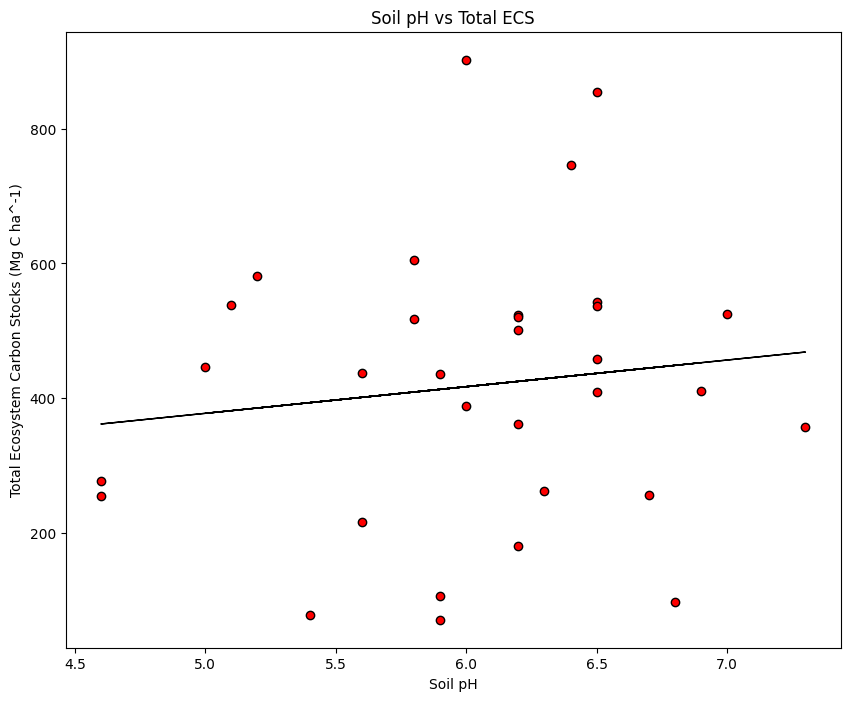

Linear Regression Equation:
y =  39.582x + 179.434
 
R squared value:
R2 = 0.016


In [9]:
#pH vs ECS linear regression and scatter plot

import matplotlib.pyplot as plt
from scipy.stats import linregress

LR_pH = stats.linregress(df['Soil pH'], df[ 'Total ECS'])

#create scatter plot
plt.figure(figsize = (10,8))
plt.scatter(df['Soil pH'], df['Total ECS'], color = 'red', edgecolor = 'black')

#making regression line overlaid on plot
x = df['Soil pH']
y_reg = LR_pH.slope*x + LR_pH.intercept
plt.plot(x, y_reg, 'k-', linewidth = 1)

plt.xlabel('Soil pH')
plt.ylabel('Total Ecosystem Carbon Stocks (Mg C ha^-1)')
plt.title(f'Soil pH vs Total ECS')
plt.grid(False)
plt.show()

print("Linear Regression Equation:")
print("y = ", str(np.round(LR_pH.slope, decimals=3)) + "x +", str(np.round(LR_pH.intercept, decimals=3)))
print(' ')
print("R squared value:")
print("R2 = " +str(np.round(LR_pH.rvalue**2, decimals=3)))

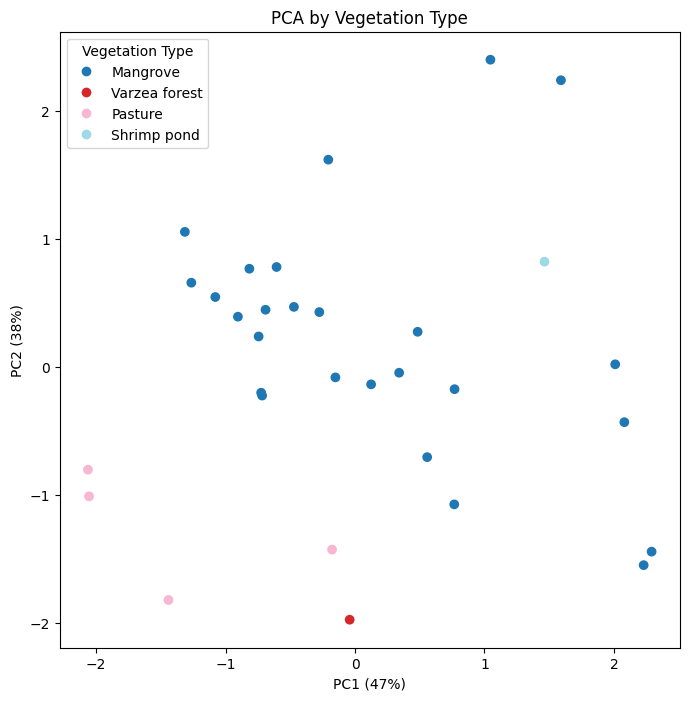

In [14]:
#3 - Dimensionality Reduction

data = df[['Soil pH', 'Soil Salinity ', 'Total ECS']]

scale = StandardScaler()
data_scaled = scale.fit_transform(data)

pca = PCA(n_components = 2)
principalComponents = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame(data = principalComponents, columns = ['PCA1', 'PCA2'])

fig, ax = plt.subplots(figsize = (8,8))

veg_categories = df.loc[data.index, 'Vegetation']

scatter_plot = ax.scatter(pca_df.iloc[:,0], pca_df.iloc[:,1], c = veg_categories.astype('category').cat.codes, cmap = 'tab20')

ax.set_xlabel("PC1 (47%)")
ax.set_ylabel("PC2 (38%)")
ax.set_title("PCA by Vegetation Type")

names, labels = scatter_plot.legend_elements()
ax.legend(names, veg_categories.unique(), title = 'Vegetation Type')


In [10]:
print(pca_df)

        PCA1      PCA2
0  -0.276017  0.426953
1  -0.904901  0.390868
2  -0.206572  1.618423
3  -0.472233  0.467541
4  -0.717837 -0.225866
5  -0.691621  0.445162
6  -0.816433  0.765876
7  -0.744857  0.236314
8  -0.606421  0.779411
9  -1.314874  1.053995
10 -1.264907  0.656684
11  0.124095 -0.137943
12  0.483730  0.272873
13 -1.079687  0.544705
14  0.340647 -0.047207
15 -0.725595 -0.203208
16  0.557251 -0.707028
17  1.590757  2.239403
18  2.291214 -1.445845
19  2.229877 -1.551417
20  0.766511 -1.076468
21 -0.151772 -0.083522
22  0.768881 -0.175772
23  2.010027  0.018726
24  2.080696 -0.433671
25  1.045989  2.399802
26  1.463489  0.821088
27 -0.041517 -1.978044
28 -2.063572 -0.804905
29 -2.055143 -1.013398
30 -0.177533 -1.429618
31 -1.441671 -1.823912


In [11]:
#explained variance
pca.explained_variance_ratio_

array([0.47493529, 0.36912853])

In [10]:
#determining weights and plotting bar chart
weights = pd.DataFrame(pca.components_.T, columns = ['PC1', 'PC2'], index = ['Soil pH', 'Soil Salinity', 'Total ECS'])

weights.plot(kind = 'bar', figsize = (8,8), edgecolor = 'black', rot=0)

plt.xlabel('Variables')
plt.ylabel('Weight')
plt.title('Principle Component Weights by Variable')
plt.axhline(0, color = 'blue', linestyle = '--', linewidth = 1)
plt.legend(title = 'Principle Components')

plt.grid(False)
plt.show()


NameError: name 'pca' is not defined